## Machine-Learning Pipeline Dieselpreisprognose

In [46]:
# Umgebung vorbereiten

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json, gc
from pathlib import Path
from datetime import datetime
from scipy.stats import linregress
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, f1_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint
import xgboost as xgb
import shap

STATION_UUID = "e1aefc4e-3ca1-4018-8d91-455b69d35d41"
DATA_DIR = Path("../data")
ML_DIR = DATA_DIR / "ml"
KERN_STUNDEN = list(range(13, 21))
SCHWELLE_ANP = 0.005

def richtung_accuracy(y_true, y_pred):
    return accuracy_score((np.array(y_true) > 0).astype(int), (np.array(y_pred) > 0).astype(int))


def richtung_f1(y_true, y_pred):
    return f1_score(
        (np.array(y_true) > 0).astype(int),
        (np.array(y_pred) > 0).astype(int),
        zero_division=0,
    )


In [ ]:
# Masterdatensatz einlesen

df_raw = pd.read_parquet(
    ML_DIR / "ml_master_dataset.parquet",
    columns=["station_uuid", "date", "preis", "kraftstoff"],
)
df = df_raw[
    (df_raw["station_uuid"] == STATION_UUID)
    & (df_raw["kraftstoff"].astype(str) == "diesel")
    & df_raw["preis"].notna()
].copy()
del df_raw

df["date"] = pd.to_datetime(df["date"])
df["stunde_bin"] = df["date"].dt.floor("h")
df["stunde_h"] = df["date"].dt.hour
df["tag"] = pd.to_datetime(df["date"].dt.date)
df = df.sort_values("date").reset_index(drop=True)


print(len(df), str(df["date"].min().date()), str(df["date"].max().date()))


78079 2017-06-09 2026-03-19


In [10]:
df.describe()

,date,preis,stunde_bin,stunde_h,tag
count,78079,78079.000000,78079,78079.000000,78079
mean,2022-08-04 00:07:06.286043648,1.537668,2022-08-03 23:45:36.597548544,13.535752,2022-08-03 10:13:27
min,2017-06-09 11:52:06,0.979000,2017-06-09 11:00:00,0.000000,2017-06-09 00:00:00
25%,2020-08-14 09:11:38.500000,1.299000,2020-08-14 09:00:00,10.000000,2020-08-14 00:00:00
50%,2022-11-26 09:03:06,1.579000,2022-11-26 09:00:00,13.000000,2022-11-26 00:00:00
75%,2024-10-11 11:11:59.500000,1.699000,2024-10-11 10:30:00,17.000000,2024-10-11 00:00:00
max,2026-03-19 21:07:02,2.389000,2026-03-19 21:00:00,23.000000,2026-03-19 00:00:00
std,NaN,0.268920,NaN,4.126099,NaN


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78079 entries, 0 to 78078
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   station_uuid  78079 non-null  str           
 1   date          78079 non-null  datetime64[ns]
 2   preis         78079 non-null  float32       
 3   kraftstoff    78079 non-null  category      
 4   stunde_bin    78079 non-null  datetime64[ns]
 5   stunde_h      78079 non-null  int32         
 6   tag           78079 non-null  datetime64[s] 
dtypes: category(1), datetime64[ns](2), datetime64[s](1), float32(1), int32(1), str(1)
memory usage: 5.7 MB


In [11]:
df.isna().sum()

station_uuid    0
date            0
preis           0
kraftstoff      0
stunde_bin      0
stunde_h        0
tag             0
dtype: int64

In [ ]:
df.head(5)

,station_uuid,date,preis,kraftstoff,stunde_bin,stunde_h,tag
0,e1aefc4e-3ca1-4018-8d91-455b69d35d41,2017-06-09 11:52:06,1.099,diesel,2017-06-09 11:00:00,11,2017-06-09
1,e1aefc4e-3ca1-4018-8d91-455b69d35d41,2017-06-09 12:18:07,1.099,diesel,2017-06-09 12:00:00,12,2017-06-09
2,e1aefc4e-3ca1-4018-8d91-455b69d35d41,2017-06-09 13:37:07,1.089,diesel,2017-06-09 13:00:00,13,2017-06-09
3,e1aefc4e-3ca1-4018-8d91-455b69d35d41,2017-06-09 16:08:06,1.079,diesel,2017-06-09 16:00:00,16,2017-06-09
4,e1aefc4e-3ca1-4018-8d91-455b69d35d41,2017-06-09 17:01:06,1.099,diesel,2017-06-09 17:00:00,17,2017-06-09


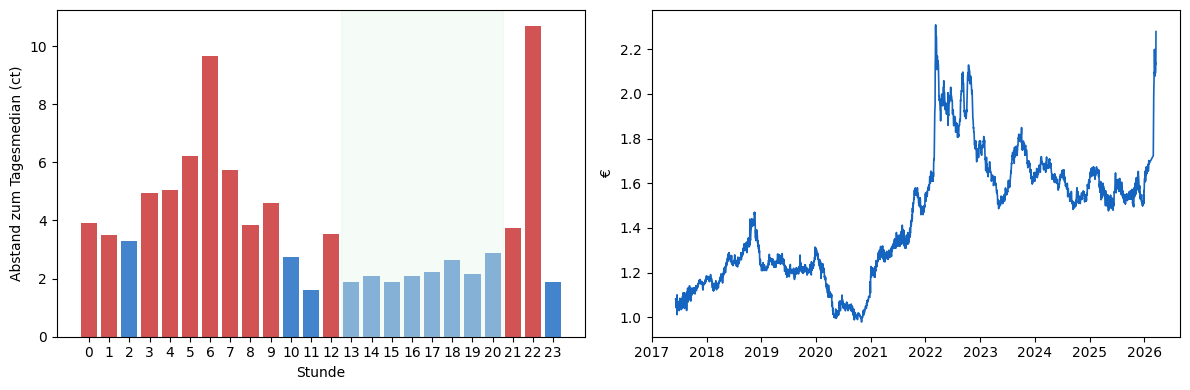

Tage kern_tag: 3172


In [ ]:
# Stunden-DF bilden
stunden = (
    df.groupby("stunde_bin")["preis"]
    .median()
    .reset_index()
    .rename(columns={"preis": "diesel"})
)
stunden["tag"] = pd.to_datetime(stunden["stunde_bin"].dt.date)
stunden["stunde_h"] = stunden["stunde_bin"].dt.hour

# Bildung von Stundenmedian, Tagesmedian 8und Abstand vom Tagesmedian
stunden_mit_tag = stunden.merge(
    stunden.groupby("tag")["diesel"].median().reset_index().rename(columns={"diesel": "tages_median"}),
    on="tag",
    how="left",
)
stunden_mit_tag["abstand"] = (stunden_mit_tag["diesel"] - stunden_mit_tag["tages_median"]).abs()
abstand_pro_stunde = stunden_mit_tag.groupby("stunde_h")["abstand"].mean().reset_index()


# Plot 1: Abstand zum Tagesmedian pro Stunde
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
farben = ["#C62828" if v > abstand_pro_stunde["abstand"].median() else "#1565C0" for v in abstand_pro_stunde["abstand"]]
ax.bar(abstand_pro_stunde["stunde_h"], abstand_pro_stunde["abstand"] * 100, color=farben, alpha=0.8)
ax.axvspan(12.5, 20.5, color="#E8F5E9", alpha=0.4)
ax.set_xlabel("Stunde")
ax.set_ylabel("Abstand zum Tagesmedian (ct)")
ax.set_xticks(range(24))

kern_tag = (
    stunden_mit_tag[stunden_mit_tag["stunde_h"].isin(KERN_STUNDEN)]
    .groupby("tag")["diesel"]
    .quantile(0.10)
    .reset_index()
    .rename(columns={"diesel": "kernpreis_p10"})
)

# Plot 2: Tageskernpreis
ax = axes[1]
ax.plot(kern_tag["tag"], kern_tag["kernpreis_p10"], color="#1565C0", lw=1.2)
ax.set_ylabel("€")
plt.tight_layout()
plt.show()


print("Tage kern_tag:", len(kern_tag))


In [15]:
print(stunden_mit_tag.head(5))

           stunde_bin  diesel        tag  stunde_h  tages_median  abstand
0 2017-06-09 11:00:00   1.099 2017-06-09        11         1.094    0.005
1 2017-06-09 12:00:00   1.099 2017-06-09        12         1.094    0.005
2 2017-06-09 13:00:00   1.089 2017-06-09        13         1.094    0.005
3 2017-06-09 16:00:00   1.079 2017-06-09        16         1.094    0.015
4 2017-06-09 17:00:00   1.089 2017-06-09        17         1.094    0.005


In [16]:
print(kern_tag.head(5))

         tag  kernpreis_p10  delta_kern  hat_erhoehung  hat_senkung  \
0 2017-06-09          1.081         NaN              0            0   
1 2017-06-10          1.070      -0.011              0            1   
2 2017-06-11          1.060      -0.010              0            1   
3 2017-06-12          1.081       0.021              1            0   
4 2017-06-13          1.042      -0.039              0            1   

   hat_anpassung  tage_seit_erhoehung  tage_seit_senkung  delta_kern_lag1  \
0              0                    1                  1              NaN   
1              1                    2                  0              NaN   
2              1                    3                  0           -0.011   
3              1                    0                  1           -0.010   
4              1                    1                  0            0.021   

   delta_kern_lag2  wochentag  ist_montag  ist_freitag  
0              NaN          4           0            

In [17]:
print(stunden.head(5))

           stunde_bin  diesel        tag  stunde_h
0 2017-06-09 11:00:00   1.099 2017-06-09        11
1 2017-06-09 12:00:00   1.099 2017-06-09        12
2 2017-06-09 13:00:00   1.089 2017-06-09        13
3 2017-06-09 16:00:00   1.079 2017-06-09        16
4 2017-06-09 17:00:00   1.089 2017-06-09        17


In [22]:
# --- Rohölpreise und EUR/USD-Daten laden und vorbereiten ---
# Laden der Brent-Futures (USD) und EUR/USD-Tageskurs
brent_tag = pd.read_csv(DATA_DIR / "brent_futures_daily.csv", parse_dates=["period"])
eur_usd = pd.read_csv(DATA_DIR / "eur_usd_rate.csv", parse_dates=["period"])

# Spalten sinnvoll benennen (period -> tag, ...), damit Join funktioniert
brent_tag = brent_tag.rename(columns={"period": "tag", "brent_futures_usd": "brent_usd"})
eur_usd = eur_usd.rename(columns={"period": "tag", "eur_usd": "eur_usd"})

# Join der Datensätze auf Tagesbasis (innerer Join auf Tag)
brent_tag = brent_tag.merge(eur_usd, on="tag", how="left")

# Brent-Preis in EUR berechnen
brent_tag["brent_eur"] = brent_tag["brent_usd"] / brent_tag["eur_usd"]

# Kalender für den vollständigen Zeitraum anlegen, damit keine Tage fehlen
_kal = pd.DataFrame({"tag": pd.date_range(kern_tag["tag"].min(), kern_tag["tag"].max(), freq="D")})

# Auf vollen Zeitraum abbilden & ggf. Werte vor/nach auffüllen
brent_tag = _kal.merge(brent_tag[["tag", "brent_eur"]], on="tag", how="left").sort_values("tag")
brent_tag["brent_eur"] = brent_tag["brent_eur"].ffill().bfill()

# Brent-Preis-Tagesänderungen berechnen (für 1, 2, 3 Tage Rückblick)
brent_tag["brent_delta1"] = brent_tag["brent_eur"].diff(1)
brent_tag["brent_delta2"] = brent_tag["brent_eur"].diff(2)
brent_tag["brent_delta3"] = brent_tag["brent_eur"].diff(3)

# --- Bearbeitung/Feature Engineering: Tageskernpreise ---
# Nach Tag sortieren und Index resetten
kern_tag = kern_tag.sort_values("tag").reset_index(drop=True)

# Preisänderungen berechnen (Differenz zum Vortag)
kern_tag["delta_kern"] = kern_tag["kernpreis_p10"].diff(1)

# Schwellenwert für Preiserhöhung/Senkung anwenden
kern_tag["hat_erhoehung"] = (kern_tag["delta_kern"] > SCHWELLE_ANP).astype(int)
kern_tag["hat_senkung"] = (kern_tag["delta_kern"] < -SCHWELLE_ANP).astype(int)
kern_tag["hat_anpassung"] = (kern_tag["delta_kern"].abs() > SCHWELLE_ANP).astype(int)

# Hilfsfunktion: Zählt Tage seit letztem Ereignis vom Typ (1), sonst aufaddieren
def tage_seit(series):
    out, z = [], 0
    for v in series:
        z = 0 if v == 1 else z + 1
        out.append(z)
    return out

# Wende Funktion auf Anpassungsereignisse an
kern_tag["tage_seit_erhoehung"] = tage_seit(kern_tag["hat_erhoehung"])
kern_tag["tage_seit_senkung"] = tage_seit(kern_tag["hat_senkung"])

# Weitere Lags & Kalenderinfos 
kern_tag["delta_kern_lag1"] = kern_tag["delta_kern"].shift(1)
kern_tag["delta_kern_lag2"] = kern_tag["delta_kern"].shift(2)
kern_tag["wochentag"] = kern_tag["tag"].dt.dayofweek  # 0 = Montag
kern_tag["ist_montag"] = (kern_tag["wochentag"] == 0).astype(int)
kern_tag["ist_freitag"] = (kern_tag["wochentag"] == 4).astype(int)

# --- Zusammenführen: Features (Tankstelle + Brent) in einem DataFrame ---
df_rf = kern_tag.merge(
    brent_tag[["tag", "brent_eur", "brent_delta1", "brent_delta2", "brent_delta3"]],
    on="tag",
    how="left",
)



In [24]:
print(df_rf.head(5))

         tag  kernpreis_p10  delta_kern  hat_erhoehung  hat_senkung  \
0 2017-06-09          1.081         NaN              0            0   
1 2017-06-10          1.070      -0.011              0            1   
2 2017-06-11          1.060      -0.010              0            1   
3 2017-06-12          1.081       0.021              1            0   
4 2017-06-13          1.042      -0.039              0            1   

   hat_anpassung  tage_seit_erhoehung  tage_seit_senkung  delta_kern_lag1  \
0              0                    1                  1              NaN   
1              1                    2                  0              NaN   
2              1                    3                  0           -0.011   
3              1                    0                  1           -0.010   
4              1                    1                  0            0.021   

   delta_kern_lag2  wochentag  ist_montag  ist_freitag  brent_eur  \
0              NaN          4           0

In [25]:
print(df_rf.info())

<class 'pandas.DataFrame'>
RangeIndex: 3172 entries, 0 to 3171
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   tag                  3172 non-null   datetime64[s]
 1   kernpreis_p10        3172 non-null   float64      
 2   delta_kern           3171 non-null   float64      
 3   hat_erhoehung        3172 non-null   int64        
 4   hat_senkung          3172 non-null   int64        
 5   hat_anpassung        3172 non-null   int64        
 6   tage_seit_erhoehung  3172 non-null   int64        
 7   tage_seit_senkung    3172 non-null   int64        
 8   delta_kern_lag1      3170 non-null   float64      
 9   delta_kern_lag2      3169 non-null   float64      
 10  wochentag            3172 non-null   int32        
 11  ist_montag           3172 non-null   int64        
 12  ist_freitag          3172 non-null   int64        
 13  brent_eur            3172 non-null   float64      
 14  bre

In [21]:
# Erzeuge DataFrame mit Tagesdaten: merge von kern_tag (Preise Tankstelle) und brent_tag (Brent-Ölpreise)
df_markt = kern_tag.merge(
    brent_tag[["tag", "brent_eur", "brent_delta1", "brent_delta2", "brent_delta3"]],
    on="tag",
    how="left",
)

# 7-Tage rollende Standardabweichung des Tageskernpreises (Unruhe im Preisverlauf, Feature für ML)
df_markt["kern_roll7_std"] = df_markt["kernpreis_p10"].rolling(7, min_periods=2).std()

# Berechne: wie stark hat sich Brent seit letzter Preis-Anpassung geändert?
brent_bei_anp = np.nan
bruck = []
for _, row in df_markt.iterrows():
    if row["hat_anpassung"] == 1 or np.isnan(brent_bei_anp):  # bei erster Anpassung oder Start neu setzen
        brent_bei_anp = row["brent_eur"]
    # Differenz zum zuletzt gesetzten "Anpassungs"-Brent, wird Feature
    bruck.append(row["brent_eur"] - brent_bei_anp if not np.isnan(brent_bei_anp) else 0.0)
df_markt["brent_druck_seit_anpassung"] = bruck


print(len(df_markt)) 


3172


In [27]:
print(df_markt.head(5))



         tag  kernpreis_p10  delta_kern  hat_erhoehung  hat_senkung  \
0 2017-06-09          1.081         NaN              0            0   
1 2017-06-10          1.070      -0.011              0            1   
2 2017-06-11          1.060      -0.010              0            1   
3 2017-06-12          1.081       0.021              1            0   
4 2017-06-13          1.042      -0.039              0            1   

   hat_anpassung  tage_seit_erhoehung  tage_seit_senkung  delta_kern_lag1  \
0              0                    1                  1              NaN   
1              1                    2                  0              NaN   
2              1                    3                  0           -0.011   
3              1                    0                  1           -0.010   
4              1                    1                  0            0.021   

   delta_kern_lag2  wochentag  ist_montag  ist_freitag  brent_eur  \
0              NaN          4           0

In [28]:
print(df_markt.info())

<class 'pandas.DataFrame'>
RangeIndex: 3172 entries, 0 to 3171
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype        
---  ------                      --------------  -----        
 0   tag                         3172 non-null   datetime64[s]
 1   kernpreis_p10               3172 non-null   float64      
 2   delta_kern                  3171 non-null   float64      
 3   hat_erhoehung               3172 non-null   int64        
 4   hat_senkung                 3172 non-null   int64        
 5   hat_anpassung               3172 non-null   int64        
 6   tage_seit_erhoehung         3172 non-null   int64        
 7   tage_seit_senkung           3172 non-null   int64        
 8   delta_kern_lag1             3170 non-null   float64      
 9   delta_kern_lag2             3169 non-null   float64      
 10  wochentag                   3172 non-null   int32        
 11  ist_montag                  3172 non-null   int64        
 12  ist_freitag      

# ml_master · eine Station · Diesel
Ziel: `K(t+1) - K(t-1)` auf Tageskern (p10, 13–20h). Modelle + SHAP, speichert RF + Metadaten.


In [ ]:
# Zielvariable berechnen

TARGET_COL = "ziel_kern_tp1_tm1"
roll3 = df_markt["brent_eur"].rolling(3, min_periods=2).mean()
df_markt["brent_roll_delta_tm1_tm3"] = roll3.shift(1) - roll3.shift(3)
df_markt[TARGET_COL] = df_markt["kernpreis_p10"].shift(-1) - df_markt["kernpreis_p10"].shift(1)
print(TARGET_COL, df_markt[TARGET_COL].describe().round(4).to_string())


ziel_kern_tp1_tm1 count    3170.0000
mean        0.0007
std         0.0231
min        -0.1270
25%        -0.0115
50%         0.0000
75%         0.0115
max         0.2180


In [ ]:
# Features, die für das Machine Learning Modell verwendet werden sollen.
FEATURES = [
    "brent_delta2",                # Änderung des Brent-Ölpreises im 2-Tages-Vergleich
    "delta_kern_lag1",             # Vorgängeränderung des Kernpreises (1 Tag zurück)
    "delta_kern_lag2",             # Vorgängeränderung des Kernpreises (2 Tage zurück)
    "tage_seit_erhoehung",         # Tage seit der letzten Preiserhöhung
    "tage_seit_senkung",           # Tage seit der letzten Preissenkung
    "wochentag",                   # Wochentag (Zahl von 0=Montag bis 6=Sonntag)
    "ist_montag",                  # Gibt an, ob der Tag ein Montag ist (0 oder 1)
    "kern_roll7_std",              # 7-Tage-Rollende Standardabweichung des Kernpreises
    "brent_druck_seit_anpassung",  # Änderung des Brent-Ölpreises seit der letzten Preis-Anpassung
    "brent_roll_delta_tm1_tm3",    # Rollierende Differenz des Brent-Preises (t-1 zu t-3)
]

# df_ok enthält nur die Zeilen von df_markt, in denen weder die Features noch das Ziel fehlende Werte (NaN) haben.
df_ok = df_markt[FEATURES + [TARGET_COL]].dropna()

# Korrelation aller Features mit dem Ziel berechnen, nach Stärke sortiert anzeigen (absolute Werte).
korr = df_ok.corr()[TARGET_COL].drop(TARGET_COL).abs().sort_values(ascending=False)
print(korr.round(3).to_string())


brent_delta2                  0.275
brent_roll_delta_tm1_tm3      0.246
tage_seit_senkung             0.226
tage_seit_erhoehung           0.218
kern_roll7_std                0.156
ist_montag                    0.116
delta_kern_lag1               0.113
wochentag                     0.093
brent_druck_seit_anpassung    0.061
delta_kern_lag2               0.040


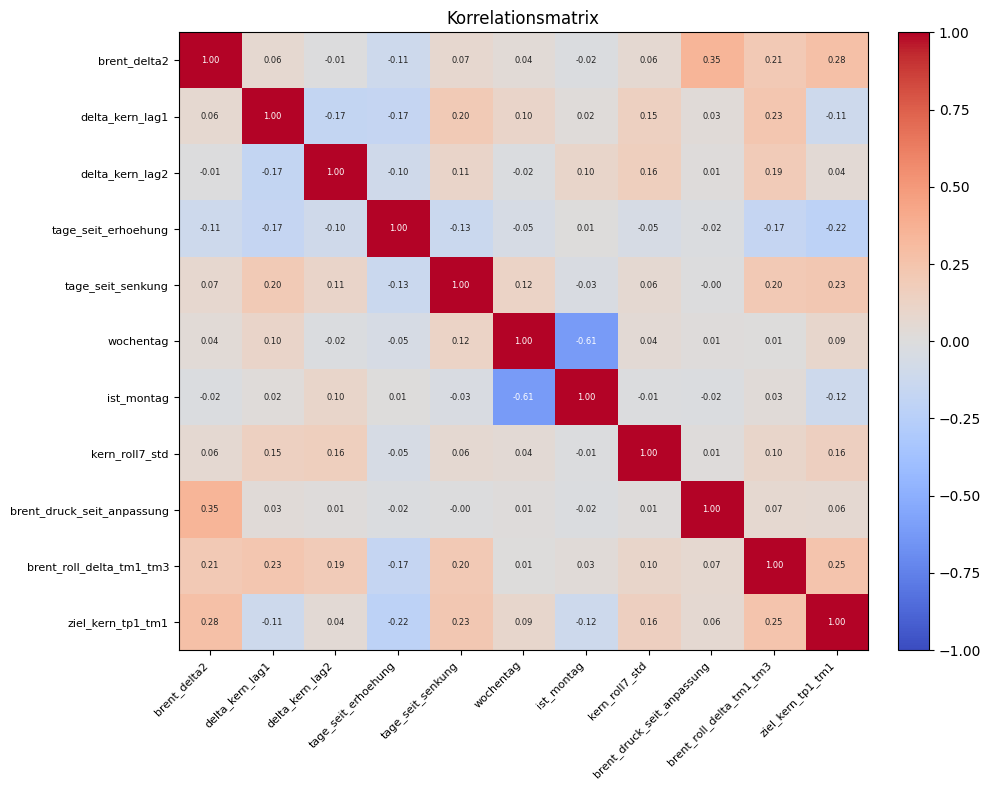

In [38]:
# Korrelationsmatrix: Features + Ziel (Pearson, nur vollständige Zeilen wie oben)
_cols = FEATURES + [TARGET_COL]
C = df_ok[_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(C.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(_cols)))
ax.set_yticks(np.arange(len(_cols)))
ax.set_xticklabels(_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(_cols, fontsize=8)
ax.set_title("Korrelationsmatrix")
for i in range(len(_cols)):
    for j in range(len(_cols)):
        v = C.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", color="white" if abs(v) > 0.55 else "#222", fontsize=6)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(ML_DIR / "feature_korrelationsmatrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
# ML-Daten vorbereiten

# Entfernt alle Zeilen mit fehlenden Werten in den benötigten Spalten.
df_ml = df_markt.dropna(subset=FEATURES + [TARGET_COL])

# Begrenzt den Datensatz auf Daten bis einschließlich 31.12.2025.
df_ml = df_ml[df_ml["tag"] <= "2025-12-31"].reset_index(drop=True)

# Einteilung der Daten in Trainings-, Validierungs- und Testzeiträume.
# tm: Trainingsdaten (vor Juli 2023)
tm = df_ml["tag"] < "2023-07-01"
# vm: Validierungsdaten (Juli 2023 bis Juni 2024)
vm = (df_ml["tag"] >= "2023-07-01") & (df_ml["tag"] < "2024-07-01")
# xm: Testdaten (ab Juli 2024)
xm = df_ml["tag"] >= "2024-07-01"

# Auswahl der jeweiligen Zeilen für Features (X) und Zielvariable (y).
X_tr = df_ml.loc[tm, FEATURES]      # Trainingsdaten, Features
y_tr = df_ml.loc[tm, TARGET_COL]    # Trainingsdaten, Zielvariable
X_va = df_ml.loc[vm, FEATURES]      # Validierungsdaten, Features
y_va = df_ml.loc[vm, TARGET_COL]    # Validierungsdaten, Zielvariable
X_te = df_ml.loc[xm, FEATURES]      # Testdaten, Features
y_te = df_ml.loc[xm, TARGET_COL]    # Testdaten, Zielvariable

# Ausgabe der Anzahl der Datenpunkte in jedem Datensatz.
print("train", tm.sum(), "val", vm.sum(), "test", xm.sum(), "total", len(df_ml))

# Anteil der Testdaten mit Zielwert > 0 (nur zur Information).
pos_te = (y_te > 0).mean()

# Definition eines kleinen Werts für eine Dummy-Vorhersage (Baseline).
_base_eps = 1e-6

# Das Baseline-Modell gibt konstant diesen Wert als Vorhersage zurück.
base_pred_te = np.full(len(y_te), _base_eps, dtype=float)

# Evaluation der Baseline-Vorhersage anhand von Richtungsgenauigkeit und mittlerem Absolutfehler.
base_rich = richtung_accuracy(y_te, base_pred_te)
base_mae = mean_absolute_error(y_te, base_pred_te)
base_f1 = richtung_f1(y_te, base_pred_te)

# Ausgabe der Baseline-Ergebnisse.
print(
    "baseline richtung",
    round(base_rich, 3),
    "F1",
    round(base_f1, 3),
    "mae ct",
    round(base_mae * 100, 2),
)


train 2206 val 364 test 548 total 3118
baseline richtung 0.48 F1 0.649 mae ct 1.7


In [48]:
# Liste zum Speichern der Ergebnisse
ergebnisse = []

# Standardisieren der Daten
sc = StandardScaler()
# Ridge Regression Modell
ridge = Ridge(alpha=1.0)
# Ridge mit den Trainingsdaten trainieren
ridge.fit(sc.fit_transform(X_tr), y_tr)
# Ridge auf Validation und Test anwenden
for split, X, y in [
    ("Val", sc.transform(X_va), y_va),
    ("Test", sc.transform(X_te), y_te)
]:
    p = ridge.predict(X)
    ergebnisse.append({
        "Modell": "Ridge " + split,
        "MAE": mean_absolute_error(y, p) * 100,
        "R2": r2_score(y, p),
        "Richtung": richtung_accuracy(y, p) * 100,
        "F1": richtung_f1(y, p),
    })

# Random Forest Modell erstellen
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
# Random Forest mit Trainingsdaten trainieren
rf.fit(X_tr, y_tr)
# Random Forest auf Validation und Test anwenden
for split, X, y in [
    ("Val", X_va, y_va),
    ("Test", X_te, y_te)
]:
    p = rf.predict(X)
    ergebnisse.append({
        "Modell": "RF " + split,
        "MAE": mean_absolute_error(y, p) * 100,
        "R2": r2_score(y, p),
        "Richtung": richtung_accuracy(y, p) * 100,
        "F1": richtung_f1(y, p),
    })

# XGBoost Modell machen
xgbm = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
# XGBoost trainieren
xgbm.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
# XGBoost auf Validation und Test anwenden
for split, X, y in [
    ("Val", X_va, y_va),
    ("Test", X_te, y_te)
]:
    p = xgbm.predict(X)
    ergebnisse.append({
        "Modell": "XGB " + split,
        "MAE": mean_absolute_error(y, p) * 100,
        "R2": r2_score(y, p),
        "Richtung": richtung_accuracy(y, p) * 100,
        "F1": richtung_f1(y, p),
    })

# Ergebnisse als DataFrame
df_erg = pd.DataFrame(ergebnisse)
# Ergebnisse für jedes Modell ausgeben
for _, r in df_erg.iterrows():
    print(
        r["Modell"],
        f"{r['MAE']:.2f}c",
        f"R2={r['R2']:.3f}",
        f"dir={r['Richtung']:.1f}%",
        f"F1={r['F1']:.3f}",
    )
# Baseline ausgeben
print(
    "baseline",
    f"{base_mae*100:.2f}c",
    f"dir={base_rich*100:.1f}%",
    f"F1={base_f1:.3f}",
)


Ridge Val 1.20c R2=0.208 dir=74.2% F1=0.740
Ridge Test 1.46c R2=0.263 dir=70.8% F1=0.698
RF Val 1.04c R2=0.387 dir=72.5% F1=0.735
RF Test 1.33c R2=0.379 dir=74.5% F1=0.745
XGB Val 1.10c R2=0.322 dir=73.6% F1=0.729
XGB Test 1.33c R2=0.385 dir=74.6% F1=0.737
baseline 1.70c dir=48.0% F1=0.649


### Modellwauswahl
- Das Random Forest Modell wurde für die weiteren Analysen ausgewählt,
obwohl der Unterschied bei den Bewertungsmetriken (z.B. MAE und R2) zum XGBoost Modell ziemlich klein war.
- Random Forest ist oft etwas leichter zu interpretieren und robuster bei kleineren Datensätzen oder mit weniger Hyperparameter-Tuning.
- Außerdem kann man die Feature-Importances und Erklärbarkeitsmethoden wie SHAP besonders gut nutzen.
- Dadurch eignet sich das Modell für den nächsten Schritt, in dem wir die Ergebnisse besser verstehen und visualisieren wollen.





In [49]:
# Hyperparameter-Tuning für Random Forest

gc.collect()  # Speicher aufräumen

# Zeitreihen-CV
tscv = TimeSeriesSplit(n_splits=3)

# Suchraum für Random Forest Parameter
param_grid = {
    "n_estimators": randint(150, 400),
    "max_depth": randint(4, 9),
    "min_samples_leaf": randint(5, 25),
    "max_features": ["sqrt", "log2", 0.5, 0.7],
    "min_samples_split": randint(2, 15),
}

# RandomizedSearchCV für Parameterauswahl
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),
    param_distributions=param_grid,
    n_iter=18,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=1,
    verbose=1,
)

# Suche starten
rf_search.fit(X_tr, y_tr)

print("Beste Parameter:", rf_search.best_params_)
print("MAE (CV, in Cent):", round(-rf_search.best_score_ * 100, 2))

# Bestes Modell anwenden
rf_final = rf_search.best_estimator_
pred_va_f = rf_final.predict(X_va)
pred_te_f = rf_final.predict(X_te)

for name, y, p in [("val", y_va, pred_va_f), ("test", y_te, pred_te_f)]:
    print(
        f"{name}:",
        f"MAE={mean_absolute_error(y,p)*100:.2f}c",
        f"R2={r2_score(y,p):.3f}",
        f"Richtungstrefferquote={richtung_accuracy(y,p)*100:.1f}%",
        f"F1={richtung_f1(y,p):.3f}",
    )

print(
    "Baseline (Test): Richtungstrefferquote",
    round(base_rich * 100, 1),
    "% · F1",
    round(base_f1, 3),
)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Beste Parameter: {'max_depth': 7, 'max_features': 0.7, 'min_samples_leaf': 7, 'min_samples_split': 6, 'n_estimators': 200}
MAE (CV, in Cent): 1.32
val: MAE=1.04c R2=0.391 Richtungstrefferquote=72.0% F1=0.727
test: MAE=1.32c R2=0.386 Richtungstrefferquote=75.0% F1=0.750
Baseline (Test): Richtungstrefferquote 48.0 % · F1 0.649


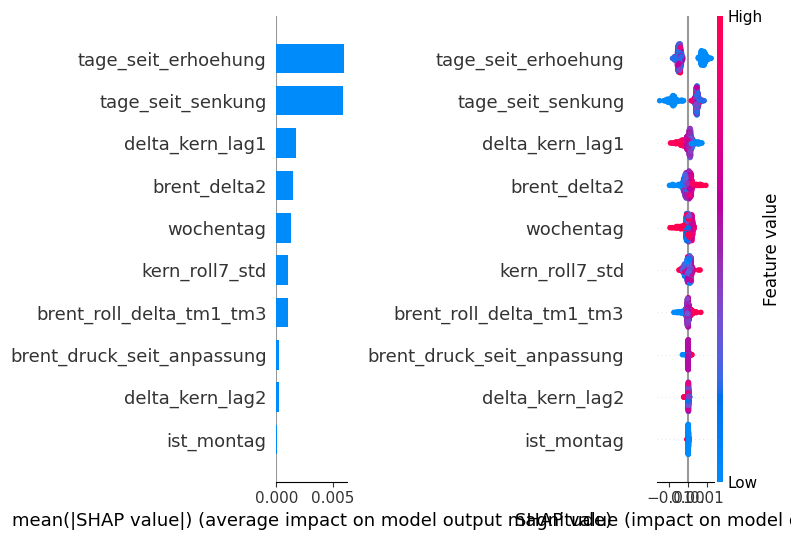

                   feature  shap_mean
       tage_seit_erhoehung   0.005984
         tage_seit_senkung   0.005871
           delta_kern_lag1   0.001751
              brent_delta2   0.001510
                 wochentag   0.001261
            kern_roll7_std   0.001054
  brent_roll_delta_tm1_tm3   0.000999
brent_druck_seit_anpassung   0.000222


In [ ]:
# SHAP-Werte berechnen und visualisieren

explainer = shap.TreeExplainer(rf_final)  # Erstellt einen Erklärer für den Random Forest
shap_values = explainer.shap_values(X_te)  # Holt die SHAP-Werte für die Testdaten

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_te, plot_type="bar", show=False, max_display=11)  # Balken (wichtigste Features)
plt.sca(axes[1])
shap.summary_plot(shap_values, X_te, plot_type="dot", show=False, max_display=11)  # Punktdiagramm

plt.tight_layout()

plt.show()

#Tabelle
shap_df = pd.DataFrame({
    "feature": X_te.columns,
    "shap_mean": np.abs(shap_values).mean(axis=0)
}).sort_values("shap_mean", ascending=False)

print(shap_df.head(8).to_string(index=False)) 


TN=206  FP=79  FN=58  TP=205


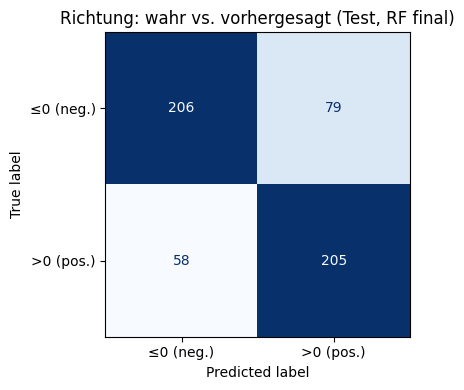

In [ ]:
# Konfusionsmatrix Richtung (Test): TN, FP, FN, TP
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_d = (np.asarray(y_te) > 0).astype(int)
y_pred_d = (np.asarray(pred_te_f) > 0).astype(int)
cm = confusion_matrix(y_true_d, y_pred_d, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["≤0 (neg.)", ">0 (pos.)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Richtung: wahr vs. vorhergesagt (Test, RF final)")
plt.tight_layout()
plt.show()

In [ ]:
# Modell speichern

joblib.dump(rf_final, ML_DIR / "modell_rf_ml_master_station_kern_tp1_tm1.pkl", compress=3)

metadaten = {
    "modell": "RandomForestRegressor (tuned)",
    "station_uuid": STATION_UUID,
    "station": "ARAL Dürener Str. 407",
    "trainiert_am": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "train_von": str(df_ml.loc[tm, "tag"].min().date()),
    "train_bis": str(df_ml.loc[tm, "tag"].max().date()),
    "val_von": str(df_ml.loc[vm, "tag"].min().date()),
    "val_bis": str(df_ml.loc[vm, "tag"].max().date()),
    "test_von": str(df_ml.loc[xm, "tag"].min().date()),
    "test_bis": str(df_ml.loc[xm, "tag"].max().date()),
    "zielvariable": "kernpreis_p10.shift(-1) - kernpreis_p10.shift(1)",
    "horizont": "2 Tage",
    "ziel_spalte": TARGET_COL,
    "kernpreis_definition": "p10 Kernstunden 13-20, Stundenmedian aus ml_master",
    "datenquelle_rohdaten": "data/ml/ml_master_dataset.parquet",
    "feature_scols": FEATURES,
    "rf_params": rf_search.best_params_,
    "baseline_richtung": "immer_steigend_konstant_positiv",
    "richtung_accuracy_val": round(richtung_accuracy(y_va, pred_va_f) * 100, 2),
    "richtung_accuracy_test": round(richtung_accuracy(y_te, pred_te_f) * 100, 2),
    "mae_test_cent": round(mean_absolute_error(y_te, pred_te_f) * 100, 2),
    "r2_test": round(r2_score(y_te, pred_te_f), 4),
    "baseline_richtung_test": round(base_rich * 100, 1),
    "delta_ueber_baseline": round(richtung_accuracy(y_te, pred_te_f) * 100 - base_rich * 100, 1),
    "shap_top3": shap_df.head(3)["feature"].tolist(),
}

with open(ML_DIR / "modell_metadaten_ml_master_station_kern_tp1_tm1.json", "w", encoding="utf-8") as f:
    json.dump(metadaten, f, indent=2, ensure_ascii=False)

print("saved pkl + json")


saved pkl + json
